Airbnb en Nueva York
Una empresa ha recolectado la información del alquiler de viviendas en Nueva York a través de la aplicación Airbnb durante el año 2019. Este conjunto de datos se utilizó para entrenar modelos de Machine Learning durante ese año, en una competición en abierto.

Ahora lo utilizaremos para llevar a cabo un estudio acerca de las variables que componen el dataset a fin de comprenderlo y obtener conclusiones sobre él.

**Paso 1**: Carga del conjunto de datos
Puedes descargar el conjunto de datos directamente desde Kaggle.com o en el siguiente enlace: https://breathecode.herokuapp.com/asset/internal-link?id=927&path=AB_NYC_2019.csv. Almacena los datos en crudo en la carpeta ./data/raw.

**Paso 2**: Realiza un EDA completo
Este paso es vital para asegurar que nos quedamos con las variables estrictamente necesarias y eliminamos las que no son relevantes o no aportan información. Utiliza el Notebook de ejemplo que trabajamos y adáptalo a este caso de uso.

Asegúrate de dividir convenientemente el conjunto de datos en train y test como hemos visto en la lección.

**Paso 3**: Guarda el conjunto de datos procesado
Después del EDA puedes guardar los datos en la carpeta ./data/processed. Asegúrate de agregar la carpeta de los datos en el .gitignore. Los datos al igual que los modelos no se deben subir a git.

<div style="background-color:#E8F6F3; padding:20px; border-left:8px solid #27AE60; border-radius:8px">

# 🌿 Paso 1: Carga del conjunto de datos

</div>

In [ ]:
# IMPORTACIONES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [ ]:
# CARGAMOS EL FICHERO CON LOS DATOS A ANALIZAR (AB_NYC_2019.csv)
train_data = pd.read_csv('/workspaces/anaisaponte-GitH-intro-ml/data/raw/AB_NYC_2019.csv')

# Visualizamos 10 registros aleatorios del dataset con sample(). Esto nos permite observar una muestra representativa de los datos,
# ya que algunos datasets pueden estar ordenados (por fecha, id, etc.).
train_data.sample(10)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
39223,30582854,Cozy Private Room w/ Full Bed - Perfect for Tr...,227679456,Jimmy,Brooklyn,Prospect-Lefferts Gardens,40.66015,-73.94251,Private room,55,1,24,2019-06-27,3.38,7,45
25497,20405868,"Large 1BR in Bay Ridge, Brooklyn",43544395,James,Brooklyn,Fort Hamilton,40.61897,-74.03675,Entire home/apt,85,1,3,2019-01-22,0.44,1,6
22896,18550111,LORIMER L TRAIN 5 minutes to the city,118378908,Jose,Brooklyn,Williamsburg,40.71493,-73.94861,Private room,65,1,2,2019-01-01,0.09,6,272
22531,18222359,LIVE BROOKLYN! Private 1 BR APT - 5 min to Subway,120804342,David,Brooklyn,Bedford-Stuyvesant,40.69460,-73.94429,Entire home/apt,109,2,112,2019-07-05,4.22,2,258
35481,28152851,PRIME location 2min to train 20min Manhattan,19303369,Hiroki,Queens,Woodside,40.74408,-73.90498,Private room,43,30,2,2019-01-14,0.28,37,0
25778,20624541,Modern apartment in the heart of Williamsburg,10132166,Aymeric,Brooklyn,Williamsburg,40.70838,-73.94645,Entire home/apt,0,5,3,2018-01-02,0.15,1,73
25643,20533007,Taaffe Playground 2,3013248,Shane,Brooklyn,Bedford-Stuyvesant,40.69199,-73.95908,Private room,72,1,1,2017-09-08,0.04,1,0
26498,21094022,"Bright, spacious room in Williamsburg",32110549,Tori,Brooklyn,Williamsburg,40.71111,-73.94792,Private room,100,2,2,2017-10-17,0.10,1,0
7472,5569167,Private room in Heart of Astoria,13728275,Elvira,Queens,Astoria,40.76272,-73.92004,Private room,50,4,1,2015-03-16,0.02,1,0
30966,23996251,Harlem,135510002,David,Manhattan,Harlem,40.81498,-73.94622,Shared room,75,2,8,2018-06-03,0.52,1,0


<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

El dataset contiene información sobre distintos alojamientos de **Airbnb ubicados en la ciudad de Nueva York durante el año 2019**.  
Incluye variables relacionadas con la **identificación del alojamiento y del anfitrión**, su **ubicación geográfica** (grupo de vecindario, vecindario, latitud y longitud), así como métricas asociadas a la **actividad del alojamiento**, como el precio, el número de reviews, la fecha de la última reseña y la disponibilidad anual.

</div>

<div style="background-color:#E8F6F3; padding:20px; border-left:8px solid #27AE60; border-radius:8px">

# 🌿 Paso 2: Realiza un EDA completo

</div>

In [3]:
# Extraigo sus columnas (variables)

train_data.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

El dataset esta compuesto por **16 variables**. 
 
Estas variables pueden clasificarse según la información que representan de la siguiente manera:

- **Identificación del alojamiento:** `id`, `name`
- **Información del anfitrión:** `host_id`, `host_name`
- **Ubicación geográfica del alojamiento:** `neighbourhood_group`, `neighbourhood`, `latitude`, `longitude`
- **Características del alojamiento:** `room_type`, `price`, `minimum_nights`
- **Actividad y popularidad del alojamiento:** `number_of_reviews`, `last_review`, `reviews_per_month`
- **Disponibilidad del alojamiento:** `availability_365`
- **Número de alojamientos que posee el anfitrión:** `calculated_host_listings_count`

</div>

In [4]:
# Veo la magnitud de los datos: 
train_data.shape

(48895, 16)

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

El dataset contiene **48,895 registros (filas)** y **16 variables (columnas)**.

</div>

In [5]:
# Observo el tipo de cada variable y la completitud de los datos
train_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

De las **16 variables** que contiene el dataset, **solo 4 presentan valores faltantes**: 
`name`, `host_name`, `last_review` y `reviews_per_month`.  
El resto de las variables están completas, lo que indica que el dataset presenta **pocos valores nulos en general**.

Además, `last_review` y `reviews_per_month` presentan el mismo número de valores no nulos, 
lo que sugiere que ambas variables están relacionadas. 

**Hipotesis**: Es probable que estos valores estén vacíos cuando un alojamiento no tiene reseñas registradas, es decir cuando  
`number_of_reviews` = 0 => `last_review` y `reviews_per_month` = NULL.

PROCEDO A VERIFICAR ESA HIPOTESIS

</div>

In [6]:
# ¿El numero de ceros en la variable `number_of_reviews`es igual al numero de NULL en `last_review` y `reviews_per_month`?
pd.Series({
    "number_of_reviews == 0": (train_data["number_of_reviews"] == 0).sum(),
    "last_review null": train_data["last_review"].isna().sum(),
    "reviews_per_month null": train_data["reviews_per_month"].isna().sum()
}).to_frame("conteo")

,conteo
number_of_reviews == 0,10052
last_review null,10052
reviews_per_month null,10052


<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

Coinciden el numero de ceros en la variable `number_of_reviews`con el numero de vacios en `last_review` y `reviews_per_month`.

Ahora verificamos que los registros en los que hay ceros(0) coincide con los registros en los que hay NULL

</div>

In [7]:
((train_data["number_of_reviews"] == 0) &
 (train_data["last_review"].isna()) &
 (train_data["reviews_per_month"].isna())
).sum()

np.int64(10052)

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

En efecto los registros en los que `number_of_reviews = 0` coincide con los registros en los que 
`last_review` y `reviews_per_month` presentan valores nulos.

**Esto corrobora mi hipotesis, por lo tanto puedo asegurar que cuando un alojamiento no tiene ninguna reseña, logicamente no tiene info en las variables `last_review` y `reviews_per_month`**

</div>

In [8]:
# Observo cuantos nulos hay por cada columna 
train_data.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

En esta tabla se muestra el **número exacto de valores nulos por columna** en el dataset.

Se confirma que únicamente cuatro variables contienen valores faltantes:  
`name` (16), `host_name` (21), `last_review` (10,052) y `reviews_per_month` (10,052).

El resto de las variables no presentan valores nulos, lo que indica que **la mayor parte del dataset está completa**. Además, se observa que los valores faltantes se concentran principalmente en `last_review` y `reviews_per_month`.

</div>

In [9]:
# Observo la misma info pero en porcentajes
(train_data.isna().sum() / len(train_data) * 100).sort_values(ascending=False).round(2)

last_review                       20.56
reviews_per_month                 20.56
host_name                          0.04
name                               0.03
neighbourhood_group                0.00
neighbourhood                      0.00
id                                 0.00
host_id                            0.00
longitude                          0.00
latitude                           0.00
room_type                          0.00
price                              0.00
number_of_reviews                  0.00
minimum_nights                     0.00
calculated_host_listings_count     0.00
availability_365                   0.00
dtype: float64

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

La tabla muestra el **porcentaje de valores nulos por columna** en el dataset.  
Se observa que la mayor proporción de valores faltantes se concentra en `last_review` y `reviews_per_month`, donde aproximadamente **20.56%** de los registros están vacíos.

En contraste, las variables `name` y `host_name` presentan porcentajes de valores faltantes **muy bajos** (inferiores al 0.05%), mientras que el resto de las variables no presentan valores nulos.

Esto indica que los valores faltantes **no están distribuidos de manera uniforme en el dataset**, sino que se concentran principalmente en variables relacionadas con la actividad de reseñas.

</div>

In [10]:
# Resumo toda la info anterior en una sola tabla

summary = pd.DataFrame({
    "Tipo de dato": train_data.dtypes,
    "Valores nulos": train_data.isna().sum(),
    "Porcentaje de nulos (%)": (train_data.isna().sum() / len(train_data) * 100).round(2)
})

summary.sort_values(by="Porcentaje de nulos (%)", ascending=False)

# NOTA: El nombre de las columnas se muestra porque Panda usa el índice común de todas las Series, por eso cada fila del nuevo DataFrame corresponde 
# a una columna del dataset original.

,Tipo de dato,Valores nulos,Porcentaje de nulos (%)
last_review,str,10052,20.56
reviews_per_month,float64,10052,20.56
host_name,str,21,0.04
name,str,16,0.03
neighbourhood_group,str,0,0.00
neighbourhood,str,0,0.00
id,int64,0,0.00
host_id,int64,0,0.00
longitude,float64,0,0.00
latitude,float64,0,0.00


<Axes: >

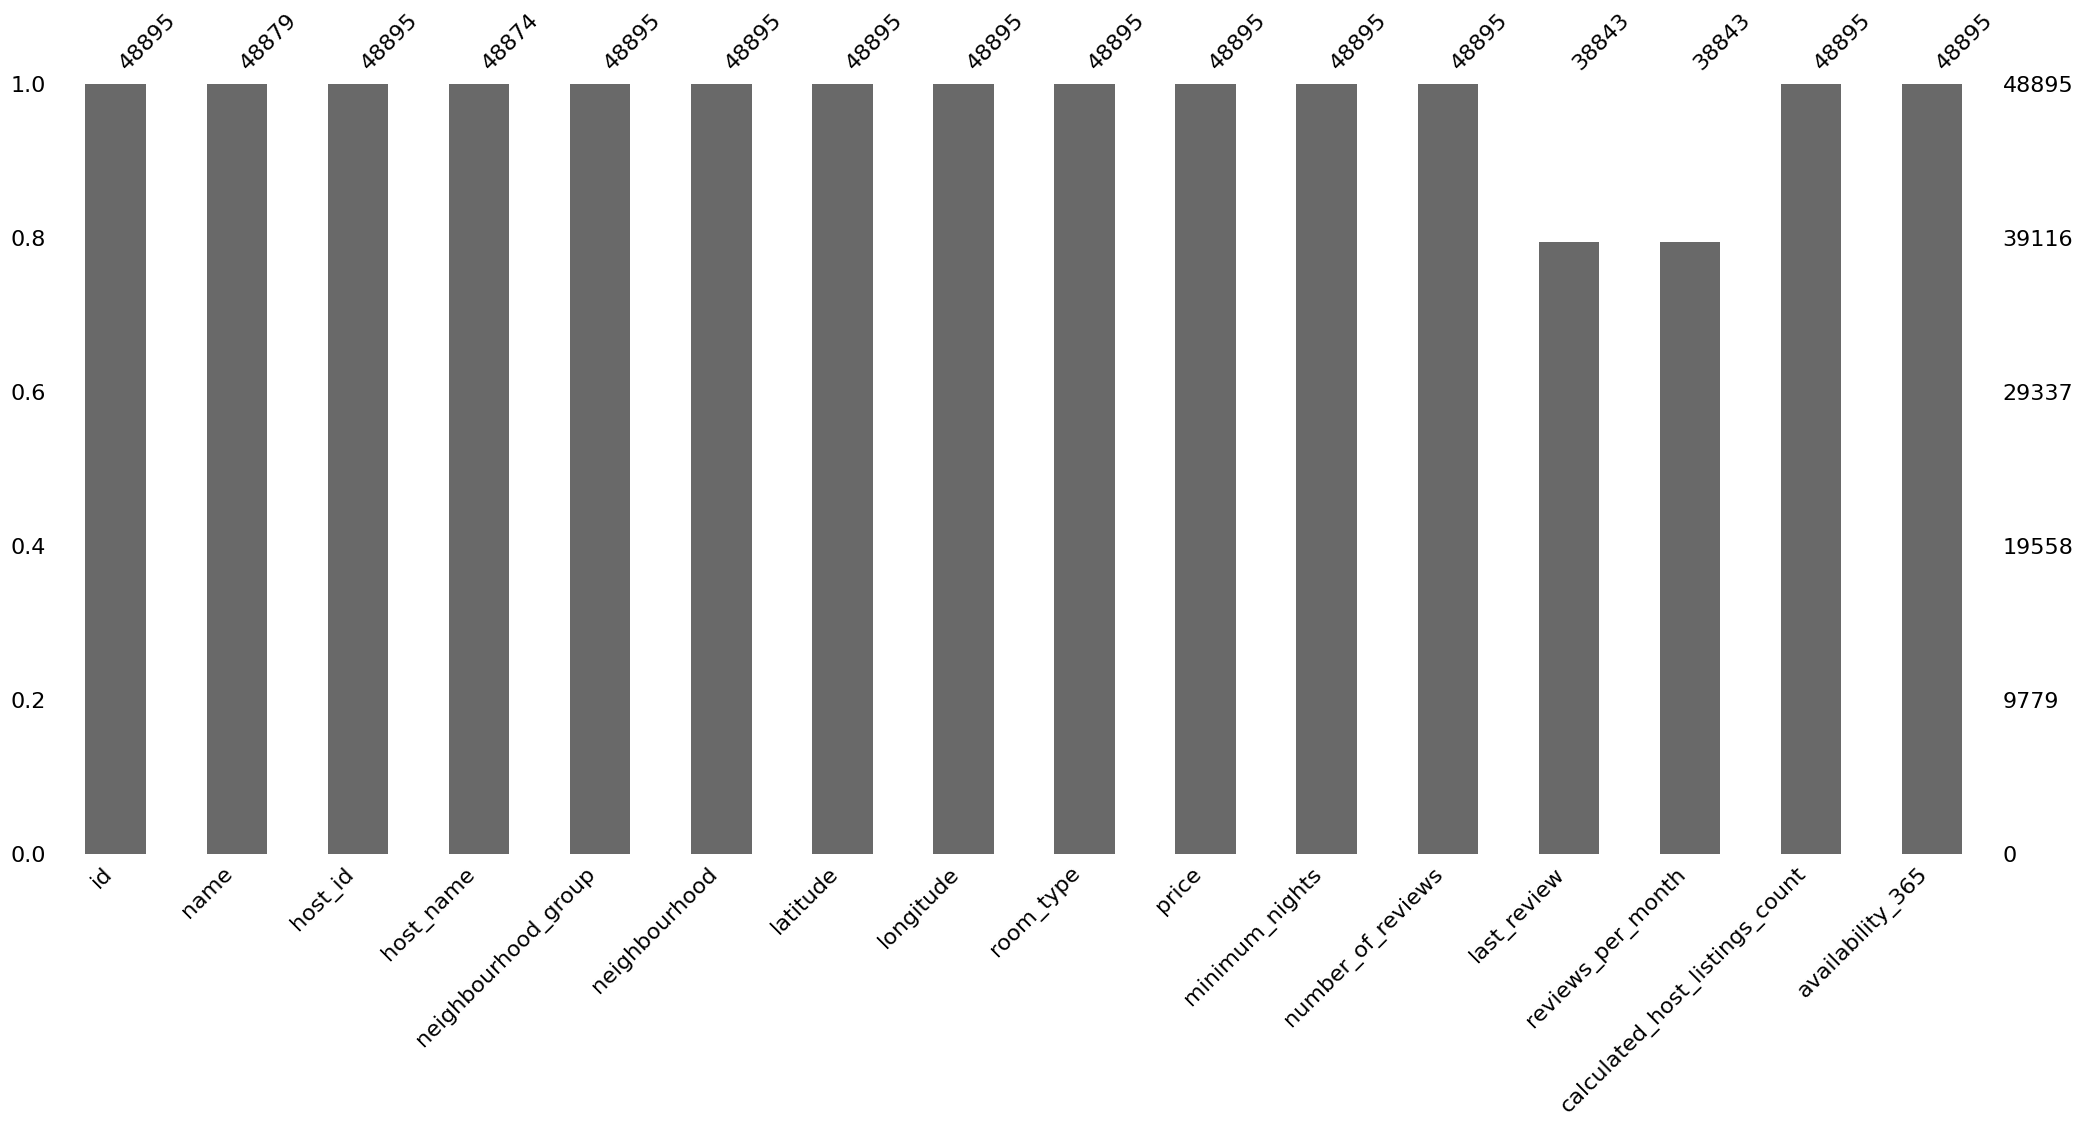

In [11]:
# Visualización de la distribución de valores nulos en el dataset.

msno.bar(train_data)


<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

La visualización del grafico de valores nulos permite identificar rápidamente la distribución de datos faltantes en el dataset.

Llama la atencion que aunque las variables `name` y `host_name` presentan un porcentaje de valores nulos, casi no se persiben en el grafico y esto ocurre por que su proporción es extremadamente baja en comparación con el tamaño total del dataset (menos del 0.05%), por lo que visualmente apenas se perciben.

Además, `last_review` y `reviews_per_month` presentan el mismo número de valores no nulos, y eso se da justo cuando la variable `number_of_review` es cero como se comprobo anteriormente. 

**En conclusion, el dataset presenta un alto nivel de completitud en la mayoría de las variables, concentrándose los valores faltantes principalmente en las variables relacionadas con la actividad de reseñas.**

</div>

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación General

El análisis de valores nulos muestra que **12 de las 16 variables del dataset están completas**, es decir, no presentan valores faltantes.

Las únicas variables que contienen valores nulos son:

1. `name`: 16 valores nulos  
2. `host_name`: 21 valores nulos  
3. `last_review`: 10,052 valores nulos  
4. `reviews_per_month`: 10,052 valores nulos  

Las variables `last_review` y `reviews_per_month` presentan exactamente **el mismo número de valores faltantes (10,052)**.

Tras verificarlo explícitamente anteriormente, se confirma que **estos valores faltantes corresponden a alojamientos que no tienen reseñas registradas** (`number_of_reviews = 0`).  Por tanto, los valores nulos en estas variables **no representan datos perdidos**, sino **la ausencia de actividad de reseñas**.

Para facilitar la interpretación del dataset y apoyar el análisis posterior, se construye un **Data Dictionary** que describe el significado de cada variable.

| Variable | Definition | Key / Values |
|----------|------------|--------------|
| id | Identificador único de cada alojamiento en Airbnb | Integer ID |
| name | Título o nombre del alojamiento | Text |
| host_id | Identificador único del anfitrión | Integer ID |
| host_name | Nombre del anfitrión que ofrece el alojamiento | Text |
| neighbourhood_group | Distrito o zona administrativa donde se encuentra el alojamiento | Manhattan, Brooklyn, Queens, Bronx, Staten Island |
| neighbourhood | Barrio específico dentro del distrito | Example: Harlem, Williamsburg |
| latitude | Latitud geográfica de la ubicación del alojamiento | Decimal coordinate |
| longitude | Longitud geográfica de la ubicación del alojamiento | Decimal coordinate |
| room_type | Tipo de alojamiento ofrecido | Entire home/apt, Private room, Shared room |
| price | Precio por noche en dólares estadounidenses | Numeric |
| minimum_nights | Número mínimo de noches requeridas para reservar | Integer |
| number_of_reviews | Número total de reseñas recibidas | Integer |
| last_review | Fecha de la reseña más reciente | Date |
| reviews_per_month | Número promedio de reseñas por mes | Float |
| calculated_host_listings_count | Número de alojamientos que tiene el anfitrión en Airbnb | Integer |
| availability_365 | Número de días que el alojamiento está disponible durante el año | Integer (0–365) |

</div>

In [12]:
# Vemos el resumen estadistico de las variables numericas: Esto nos permite observar la distribución de las variables numéricas 
# del dataset, como el precio, el número mínimo de noches o el número de reseñas, lo que ayuda a detectar posibles valores extremos 
# o patrones en los datos.

pd.options.display.float_format = '{:.2f}'.format # Para eliminar la notación cientifica
train_data.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,48895.00,38843.00,48895.00,48895.00
mean,19017143.24,67620010.65,40.73,-73.95,152.72,7.03,23.27,1.37,7.14,112.78
std,10983108.39,78610967.03,0.05,0.05,240.15,20.51,44.55,1.68,32.95,131.62
min,2539.00,2438.00,40.50,-74.24,0.00,1.00,0.00,0.01,1.00,0.00
25%,9471945.00,7822033.00,40.69,-73.98,69.00,1.00,1.00,0.19,1.00,0.00
50%,19677284.00,30793816.00,40.72,-73.96,106.00,3.00,5.00,0.72,1.00,45.00
75%,29152178.50,107434423.00,40.76,-73.94,175.00,5.00,24.00,2.02,2.00,227.00
max,36487245.00,274321313.00,40.91,-73.71,10000.00,1250.00,629.00,58.50,327.00,365.00


<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

#### Variable `price`

- **Media:** 152.72 dólares por noche  
- **Mediana:** 106 dólares  

La diferencia entre la media y la mediana sugiere que la distribución del precio está **sesgada hacia valores altos**, es decir, existen alojamientos con precios muy elevados que aumentan el promedio.

En cuanto a los **cuartiles**:

- **Q1 (25%) = 69 dólares**
- **Q3 (75%) = 175 dólares**

Esto indica que el **50% central de los precios se encuentra entre 69 y 175 dólares por noche** (rango intercuartílico).

Sin embargo, el **precio máximo alcanza los 10,000 dólares**, lo que evidencia la presencia de **valores extremos (outliers)** en esta variable.

---

#### Variable `number_of_reviews`

- **Media:** 23.27 reseñas  
- **Mediana:** 5 reseñas  

La media es considerablemente mayor que la mediana, lo que sugiere que **algunos alojamientos tienen un número muy alto de reseñas que eleva el promedio**.

En cuanto a los **cuartiles**:

- **Q1 (25%) = 1 reseña**
- **Q3 (75%) = 24 reseñas**

Esto indica que **la mitad de los alojamientos tiene entre 1 y 24 reseñas**, lo que sugiere que la mayoría de los alojamientos tienen relativamente pocas reseñas.

No obstante, algunos alojamientos presentan valores mucho más elevados, con un **máximo de 629 reseñas**, lo que indica la presencia de **valores extremos en esta variable**.

---

#### Variable `minimum_nights`

- **Media:** 7.03 noches  
- **Mediana:** 3 noches  

La diferencia entre la media y la mediana sugiere que algunos alojamientos requieren **estancias mínimas mucho más largas que la mayoría**, lo que incrementa el promedio.

En cuanto a los **cuartiles**:

- **Q1 (25%) = 1 noche**
- **Q3 (75%) = 5 noches**

Esto indica que **la mitad de los alojamientos requiere entre 1 y 5 noches mínimas para reservar**.

Sin embargo, el **valor máximo alcanza las 1250 noches**, lo que parece inusual y sugiere la presencia de **valores extremos o reglas particulares establecidas por algunos anfitriones**.

---

### Conclusión preliminar

En general, las variables `price`, `number_of_reviews` y `minimum_nights` presentan **distribuciones sesgadas hacia valores altos**, con la presencia de **outliers significativos**. Estos valores extremos podrían requerir un análisis más detallado en etapas posteriores del **análisis exploratorio de datos (EDA)**.

</div>

In [13]:
# Observo cuántas variables hay de cada tipo de dato en el dataset.
train_data.dtypes.value_counts()

int64      7
str        6
float64    3
Name: count, dtype: int64

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

El dataset contiene una combinación de variables numéricas (`int64`, `float64`) y variables de tipo texto (`str`). Además, las variables del dataset pueden clasificarse según la naturaleza de la información que representan:

- **Variables numéricas:** contienen valores cuantitativos sobre los que se pueden realizar operaciones matemáticas. En este dataset encontramos:  
`price`, `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `availability_365`, `calculated_host_listings_count`.

- **Variables categóricas:** representan categorías o etiquetas que describen características del alojamiento. A primera vista, variables como  
`room_type`, `neighbourhood_group` y `neighbourhood` podrían pertenecer a este grupo.

- **Variables identificadoras:** se utilizan para identificar de forma única cada registro o entidad del dataset, pero normalmente no aportan valor analítico directo. En este caso:  
`id`, `host_id`.

- **Variables geográficas:** contienen información sobre la ubicación del alojamiento:  
`latitude`, `longitude`.

- **Variables textuales:** contienen información descriptiva en formato texto, como:  
`name`, `host_name`.

- **Variables temporales:** representan información relacionada con fechas o tiempo. En este dataset:  
`last_review`.

Esta clasificación es **una primera aproximación conceptual**.  
En particular, será necesario **validar si algunas variables de tipo `str` deben tratarse como categóricas, textuales o temporales**, ya que el tipo de dato en Pandas no siempre refleja su naturaleza analítica real.

Validemos que realmente `room_type`, `neighbourhood_group` y `neighbourhood` pueden considerarse variables categoricas

</div>

In [14]:
train_data['room_type'].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room']
Length: 3, dtype: str

<Axes: xlabel='room_type', ylabel='count'>

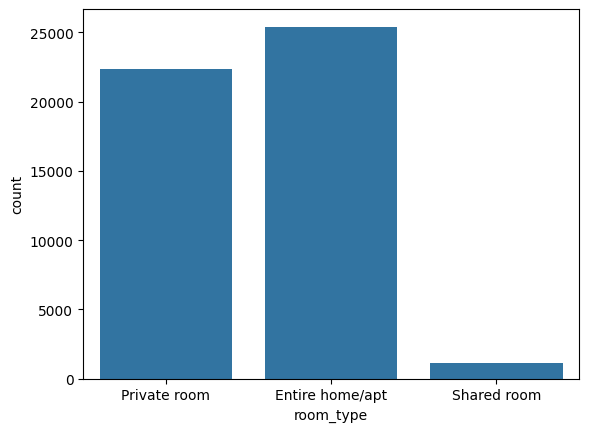

In [15]:
sns.countplot(data = train_data, x = 'room_type')

In [16]:
train_data['neighbourhood_group'].unique()

<StringArray>
['Brooklyn', 'Manhattan', 'Queens', 'Staten Island', 'Bronx']
Length: 5, dtype: str

<Axes: xlabel='neighbourhood_group', ylabel='count'>

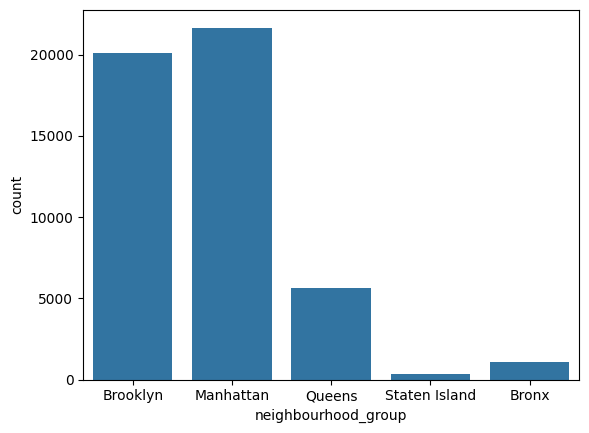

In [17]:
sns.countplot(data = train_data, x = 'neighbourhood_group')

In [18]:
train_data['neighbourhood'].unique()

<StringArray>
[        'Kensington',            'Midtown',             'Harlem',
       'Clinton Hill',        'East Harlem',        'Murray Hill',
 'Bedford-Stuyvesant',     'Hell's Kitchen',    'Upper West Side',
          'Chinatown',
 ...
     'Fort Wadsworth',           'Rosebank',          'Unionport',
         'Mill Basin',      'Arden Heights',        'Bull's Head',
           'New Dorp',          'Rossville',       'Breezy Point',
        'Willowbrook']
Length: 221, dtype: str

<Axes: xlabel='neighbourhood', ylabel='count'>

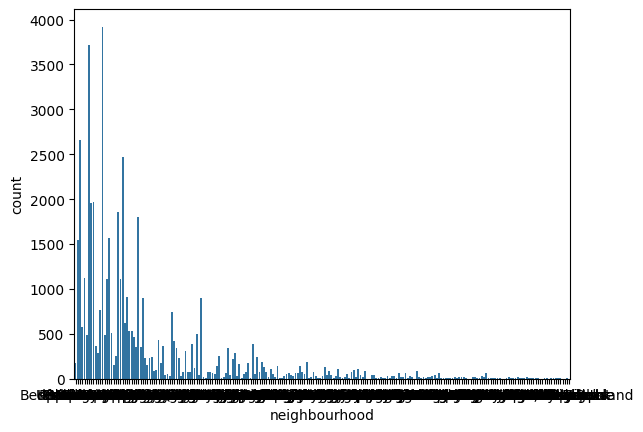

In [19]:
sns.countplot(data = train_data, x = 'neighbourhood')

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

El análisis de los valores únicos muestra que:

- `room_type` contiene **3 categorías** (`Private room`, `Entire home/apt`, `Shared room`), lo que confirma que se trata de una **variable categórica clara**.
- `neighbourhood_group` contiene **5 categorías** correspondientes a los distritos principales de la ciudad (`Brooklyn`, `Manhattan`, `Queens`, `Staten Island`, `Bronx`), por lo que también puede considerarse una **variable categórica**.
- `neighbourhood`, en cambio, contiene **221 categorías distintas**, lo que indica una **alta cardinalidad**. Aunque conceptualmente representa categorías geográficas, su gran número de valores distintos hace que no siempre pueda ser tratada como una variable categórica.

Por tanto, en una primera aproximación, `room_type` y `neighbourhood_group` pueden considerarse **variables categóricas claras**, mientras que `neighbourhood` podría requerir un tratamiento especial debido a su **alta cardinalidad**.

</div>

In [20]:
# Veamos si realmente el id y el host_id son unicos

print(train_data['id'].duplicated().sum())
print(train_data['host_id'].duplicated().sum())


0
11438


In [21]:
print ("La columna 'ID' tiene duplicados: ")
print(train_data['id'].duplicated().value_counts())
print ("La columna 'HOST_ID' tiene duplicados: ")
print(train_data['host_id'].duplicated().value_counts())

La columna 'ID' tiene duplicados: 
id
False    48895
Name: count, dtype: int64
La columna 'HOST_ID' tiene duplicados: 
host_id
False    37457
True     11438
Name: count, dtype: int64


<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

La variable `id`, que identifica de forma única cada alojamiento, no presenta duplicados, lo que confirma que cada registro corresponde a un alojamiento distinto.

En cambio, la variable `host_id` presenta 11 438 valores duplicados. Esto es esperable, ya que un mismo anfitrión puede gestionar múltiples alojamientos en la plataforma. Por tanto, `host_id` no identifica registros únicos, sino anfitriones que pueden estar asociados a varios alojamientos.

Estaria interesante ver la distribución de host como mas de un alojamiento </Pendiente/>

</div>

In [22]:
# Veamos si existen filas duplicadas en el dataset 
train_data.drop(columns=['id']).duplicated().sum()

# NOTA_1: se elimina la columna 'id' por que esta identifica univocamente cada registro lo qu enunca nos permitiria identificar duplicados por fila
# NOTA_2: Este paso crea una copia temporal de dataset en memoria y sobre esa se cuentan los duplicados de las filas

np.int64(0)

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

En esta etapa del EDA **no se identifican filas duplicadas en el dataset**.

En cuanto a las variables, existen algunas que actúan como identificadores (`id`, `host_id`) o contienen información textual libre (`name`, `host_name`). Aunque estas variables podrían no ser relevantes para ciertos análisis estadísticos o para futuros modelos predictivos y como no se tiene un objetivo específico del estudio se decide mantenerlas todas para comprender mejor la estructura del dataset.

</div>

## Analisis univariante:

### El análisis univariante significa: Analizar una variable a la vez para entender su distribución.

#### Comenzamos viendo los histogramas de las variables numéricas

#### Variables numericas: 
- price
- minimum_nights
- number_of_reviews
- reviews_per_month
- availability_365
- calculated_host_listings_count

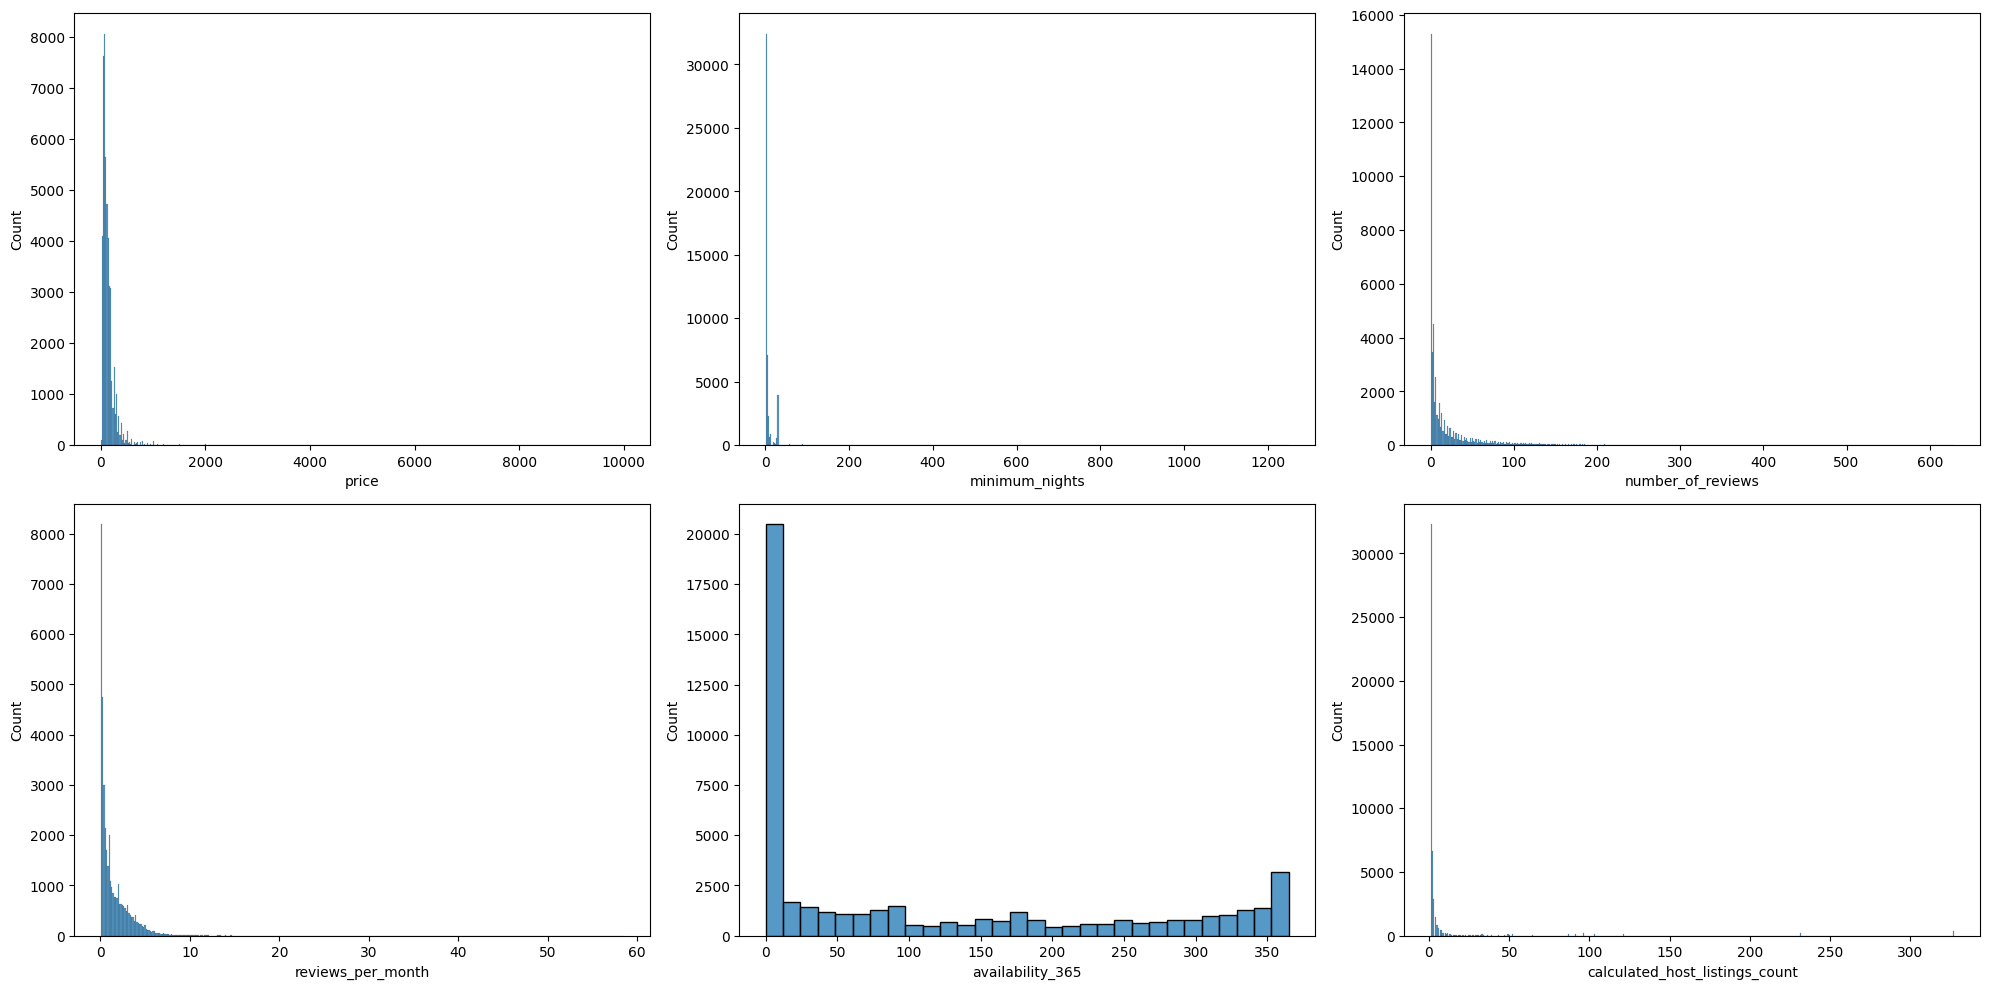

In [23]:
fig, axis = plt.subplots(2, 3, figsize=(20, 10))

#CREAMOS UN HISTOGRAMA MÚLTIPLE
sns.histplot(data=train_data, x='price', ax=axis[0,0])
sns.histplot(data=train_data, x='minimum_nights', ax=axis[0,1])
sns.histplot(data=train_data, x='number_of_reviews', ax=axis[0,2])
sns.histplot(data=train_data, x='reviews_per_month', ax=axis[1,0])
sns.histplot(data=train_data, x='availability_365', ax=axis[1,1])
sns.histplot(data=train_data, x='calculated_host_listings_count', ax=axis[1,2])

#AJUSTAR LAYAUT
plt.tight_layout()

#MOSTRAMOS EL PLOT
plt.show()

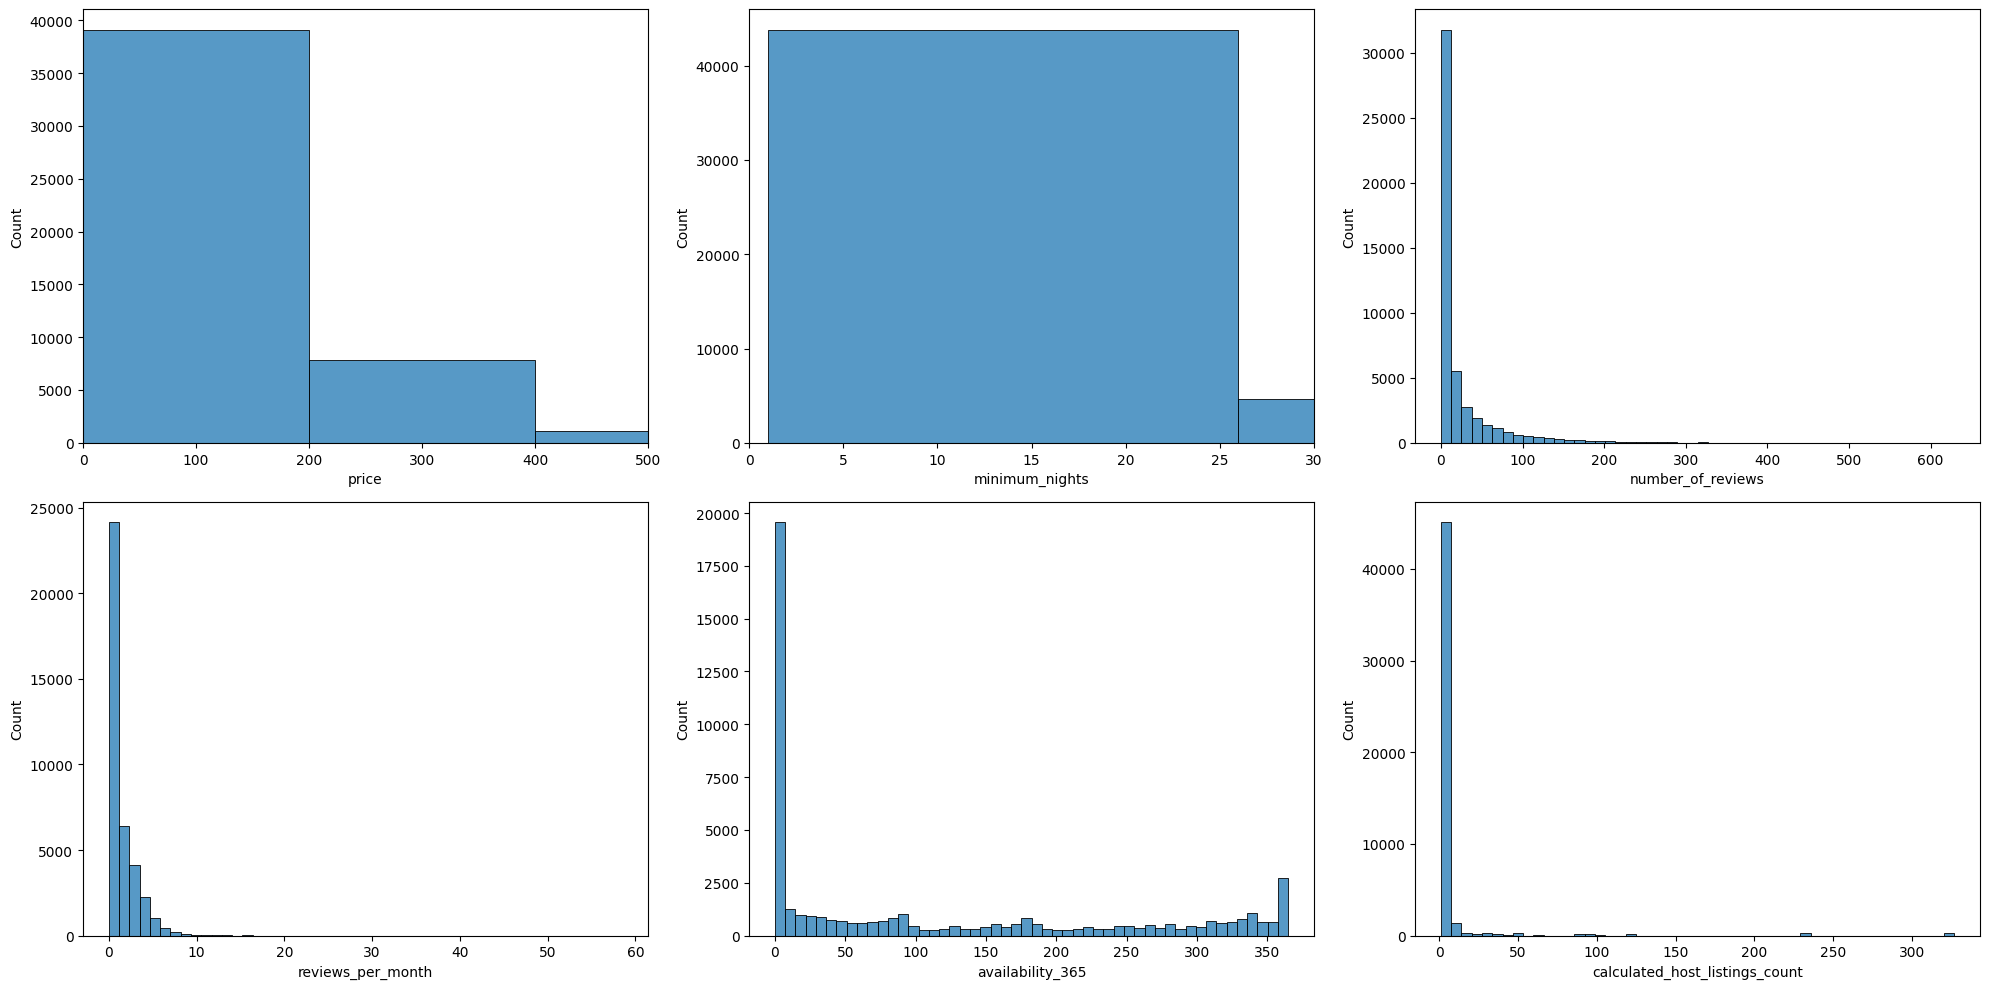

In [24]:
# Mejoramos la escala para poder visualizar mejor las graficas dado que los valores extremos hacia la derecha aplastan las graficas

fig, axis = plt.subplots(2,3, figsize=(20,10))

sns.histplot(train_data["price"], bins=50, ax=axis[0,0])
axis[0,0].set_xlim(0,500)

sns.histplot(train_data["minimum_nights"], bins=50, ax=axis[0,1])
axis[0,1].set_xlim(0,30)

sns.histplot(train_data["number_of_reviews"], bins=50, ax=axis[0,2])

sns.histplot(train_data["reviews_per_month"], bins=50, ax=axis[1,0])

sns.histplot(train_data["availability_365"], bins=50, ax=axis[1,1])

sns.histplot(train_data["calculated_host_listings_count"], bins=50, ax=axis[1,2])

plt.tight_layout()
plt.show()

#### Ahora los graficos de bigotes (boxplot) de las variables numéricas

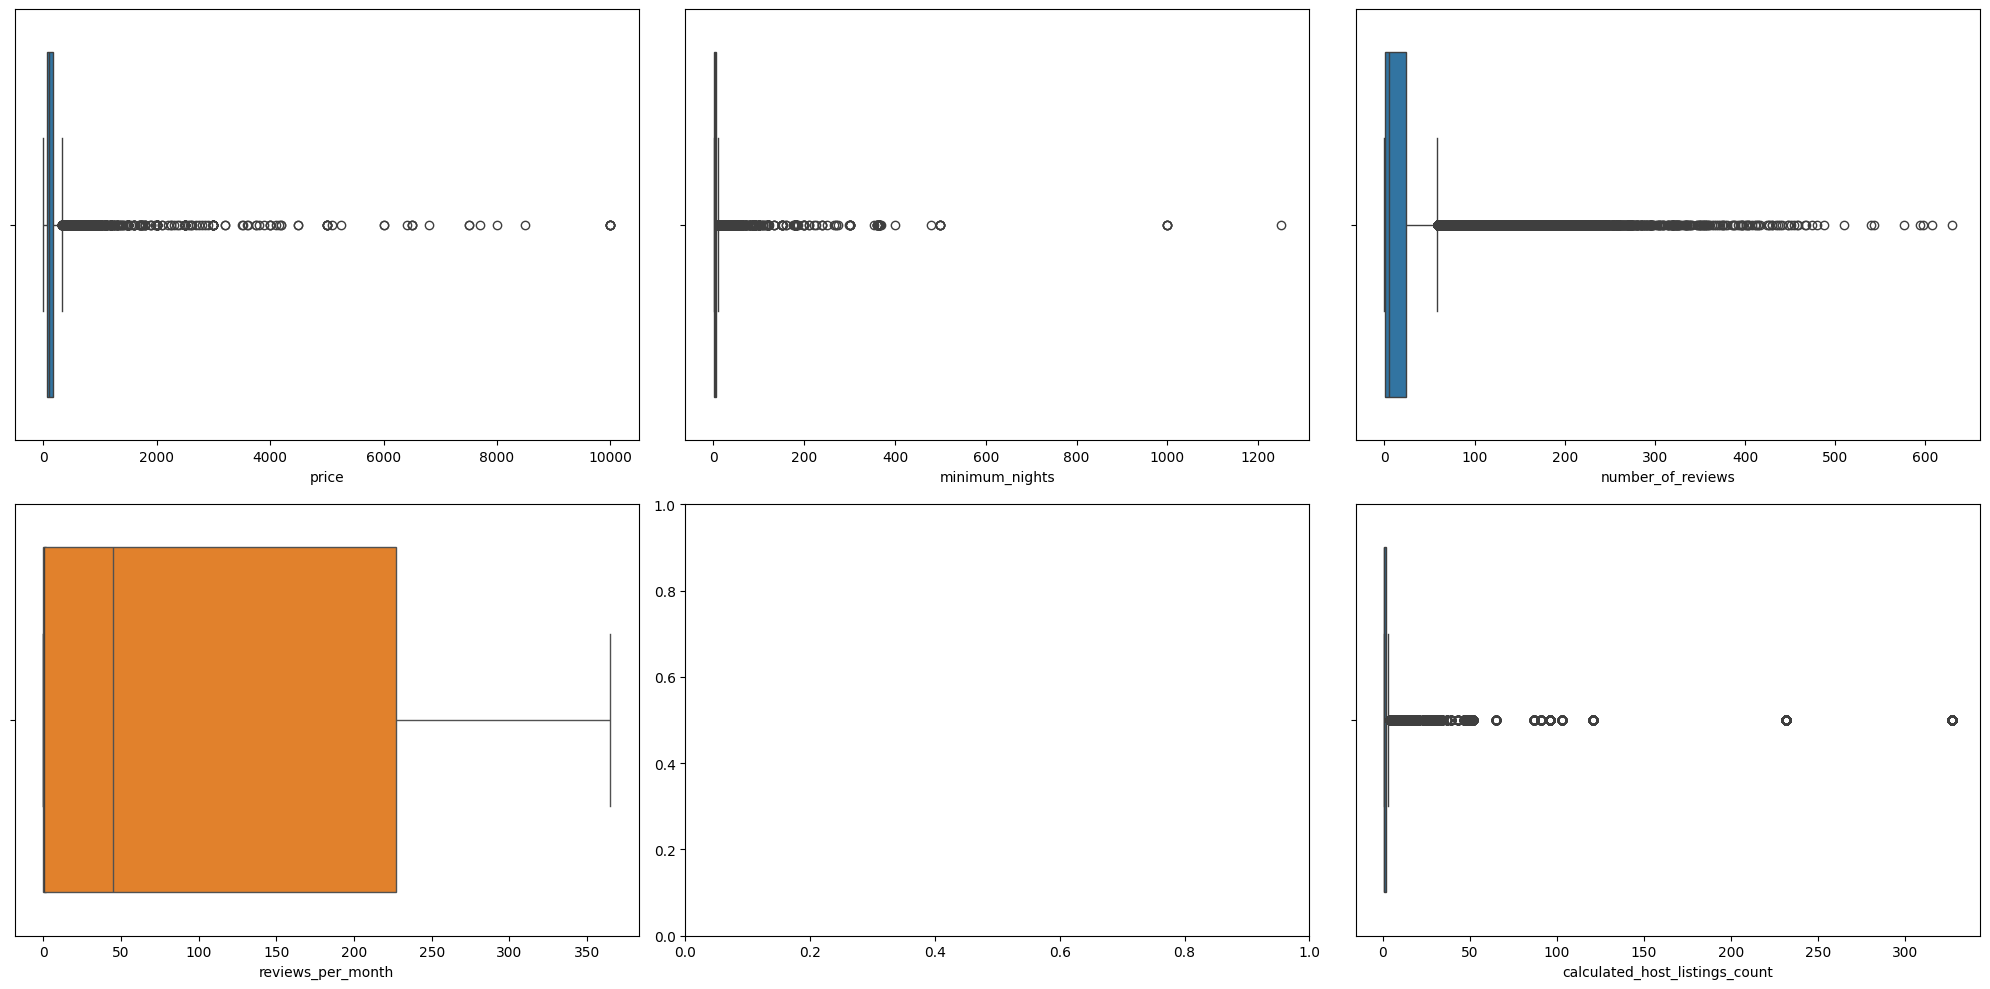

In [25]:
fig, axis = plt.subplots(2, 3, figsize=(20, 10))

#CREAMOS UN BOXPLOT MÚLTIPLE
sns.boxplot(ax=axis[0,0], data=train_data, x="price")
sns.boxplot(ax=axis[0,1], data=train_data, x="minimum_nights")
sns.boxplot(ax=axis[0,2], data=train_data, x="number_of_reviews")
sns.boxplot(ax=axis[1,0], data=train_data, x="reviews_per_month")
sns.boxplot(ax=axis[1,0], data=train_data, x="availability_365")
sns.boxplot(ax=axis[1,2], data=train_data, x="calculated_host_listings_count")

#AJUSTAR LAYAUT
plt.tight_layout()

#MOSTRAMOS EL PLOT
plt.show()

<div style="background-color:#EAF2F8; padding:15px; border-radius:10px">

### 💡 Observación

Las variables numéricas presentan distribuciones fuertemente sesgadas hacia la derecha, con la mayoría de los valores concentrados en rangos bajos y una cola larga de valores extremos. 

`price`

- la mayoría de alojamientos (>35000) tienen precios bajos entre 0 y 200

- hay algunos extremadamente caros. Ej: 10000

`minimum_nights`

- la mayoría (>40000) pide pocas noches, entre 2 y 26

- Solo unos pocos (<5000) piden entre 26 y 30 noches, pero hay valores extremos hasta alcanzar el valor maximo de 1250 noches

`number_of_reviews`

- muchos alojamientos (>30000) tienen pocas reviews, entre 0 y 100

- Solo unos pocos tienen muchas, hasta llegar a un maximo de 629 reviews

´reviews_per_month´

- la mayoría recibe pocas reseñas al mes

´availability_365´

- muchos listings tienen alta disponibilidad

`calculated_host_listings_count`

- la mayoría de hosts tienen pocos alojamientos

- unos pocos tienen muchísimos

</div>

In [26]:
train_data['reviews_per_month'].max()

np.float64(58.5)